# Tahap 3: Evaluasi Kinerja Model & Analisis Hasil

Pada tahap ini, kita mengukur seberapa akurat model JST Backpropagation yang telah dibuat menggunakan metrik standar regresi:
1. **MSE (Mean Squared Error)**: Rata-rata kuadrat selisih antara prediksi dan aktual.
2. **RMSE (Root Mean Squared Error)**: Akar dari MSE, memberikan gambaran error dalam satuan harga (Rp).
3. **MAE (Mean Absolute Error)**: Rata-rata selisih absolut antara prediksi dan aktual.

Selain itu, kita melakukan visualisasi mendalam untuk menganalisis fluktuasi error.

Data hasil prediksi berhasil dimuat.

--- HASIL EVALUASI MODEL JST ---
                                 Metrik         Nilai
0              Mean Squared Error (MSE)  13126.232072
1        Root Mean Squared Error (RMSE)    114.569769
2             Mean Absolute Error (MAE)     92.848015
3  Mean Absolute Percentage Error(MAPE)      0.751163


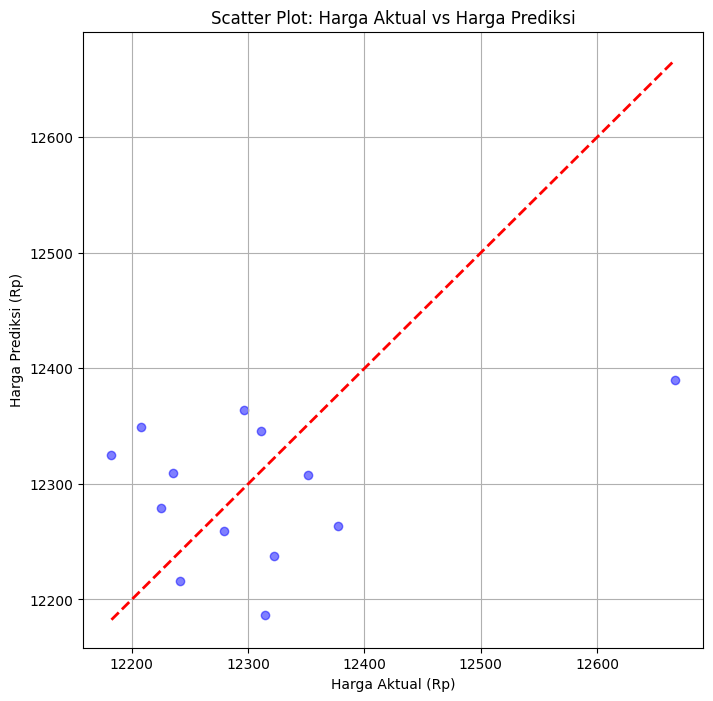

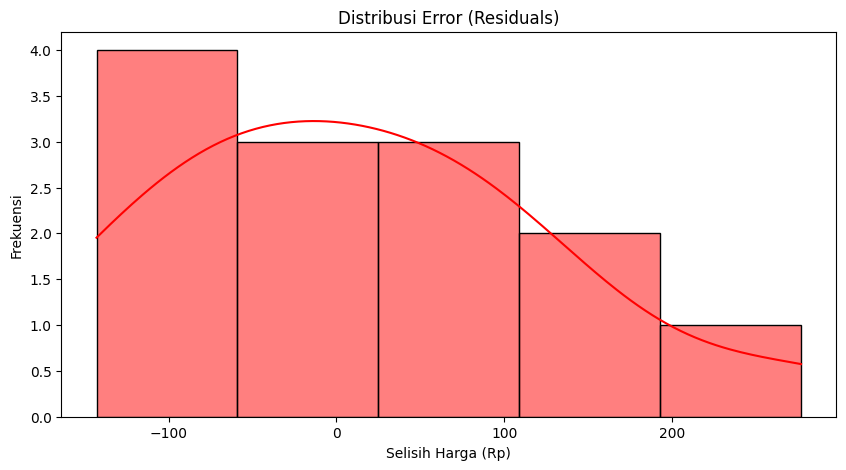

Rata-rata selisih harga (Error MAE): Rp 92.85


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load Hasil Prediksi
# Mengambil data yang telah disimpan dari notebook model_training.ipynb
try:
    df_eval = pd.read_csv('prediction_results.csv')
    y_actual = df_eval['actual'].values
    y_pred = df_eval['prediction'].values
    print("Data hasil prediksi berhasil dimuat.")
except FileNotFoundError:
    print("Error: File 'prediction_results.csv' tidak ditemukan.")
    print("Jalankan model_training telebih dulu.")


def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    nonzero_mask = y_true != 0
    if np.any(nonzero_mask):
        mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    else:
        mape = np.nan
    return mse, rmse, mae, mape

# 2. Tampilkan Tabel Evaluasi
if 'y_actual' in locals():
    mse, rmse, mae, mape = calculate_metrics(y_actual, y_pred)
    results_df = pd.DataFrame({
        'Metrik': ['Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)', 'Mean Absolute Percentage Error(MAPE)'],
        'Nilai': [mse, rmse, mae, mape]
    })
    print("\n--- HASIL EVALUASI MODEL JST ---")
    print(results_df)

    # 3. Visualisasi Scatter Plot (Aktual vs Prediksi)
    plt.figure(figsize=(8,8))
    plt.scatter(y_actual, y_pred, alpha=0.5, color='blue')
    plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
    plt.title('Scatter Plot: Harga Aktual vs Harga Prediksi')
    plt.xlabel('Harga Aktual (Rp)')
    plt.ylabel('Harga Prediksi (Rp)')
    plt.grid(True)
    plt.show()

    # 4. Analisis Distribusi Error (Residuals)
    residuals = y_actual - y_pred
    plt.figure(figsize=(10,5))
    sns.histplot(residuals, kde=True, color='red')
    plt.title('Distribusi Error (Residuals)')
    plt.xlabel('Selisih Harga (Rp)')
    plt.ylabel('Frekuensi')
    plt.show()
    print(f"Rata-rata selisih harga (Error MAE): Rp {mae:.2f}")


### Analisis Untuk Bab 4 (Pembahasan):
1. **Akurasi Model**: Jika RMSE rendah (misal < 5% dari rata-rata harga), model dianggap sangat akurat.
2. **Pola Residual**: Jika distribusi error berpusat di angka 0, model tidak memiliki bias yang signifikan.
3. **Penyebab Error**: Diskusikan jika ada lonjakan harga mendadak (anomali) yang tidak tertangkap oleh JST, misalnya karena faktor musiman atau kebijakan pemerintah.